I'll create a visual example showing how level-wise and leaf-wise tree growth differ on a simple binary classification problem.Now let me create an interactive visualization comparing level-wise and leaf-wise tree growth.Now let me walk through the key differences with a concrete example in code:Now let's run it to show the concrete differences:Let me install the required packages:Perfect! Now let me create a detailed comparison document:## What the example shows

**Key findings from the code run:**

### 1. **Level-wise (XGBoost, max_depth=3)**
- **Train AUC: 0.8082** → More constrained, doesn't memorize
- **Val-Test Gap: -0.0111** → Consistent across splits
- **Safer but potentially underfitting** — the balanced structure doesn't allow fitting the most complex patterns

### 2. **Leaf-wise (LightGBM, unregularized) — The Overfitting Trap**
- **Train AUC: 0.9999** ⚠️ **Perfect on training data!**
- **Val-Test Gap: -0.0389** → Largest gap, signals overfitting
- **Why?** With `min_data_in_leaf=1`, the tree creates leaves with just 1 sample. It memorizes noise in your training set, including fraudulent patterns that don't generalize.

### 3. **Leaf-wise (LightGBM, regularized) — The Sweet Spot**
- **Train AUC: 0.8924** → Still high, but realistic
- **Val-Test Gap: -0.0227** → Much smaller gap
- **How?** `min_data_in_leaf=50` forces each leaf to represent at least 50 examples (inlcudes both fraudulant and non-fraud examples). This prevents the tree from fitting isolated noise cases. Combined with `lambda_l1/l2` regularization on leaf weights, the tree stays generalizable.

---

## For Your SentinelPay Project

**Leaf-wise is powerful but needs guardrails:**

```python
# ❌ DON'T DO THIS (Overfitting city)
lgb = LGBMClassifier(
    num_leaves=64,
    min_data_in_leaf=1,  # DANGER: Single-sample leaves
    lambda_l1=0,
    lambda_l2=0
)

# ✓ DO THIS (Controlled leaf-wise growth)
lgb = LGBMClassifier(
    num_leaves=16,           # Start conservative (2^4)
    n_estimators=200,        # Let boosting rounds compensate
    learning_rate=0.05,      # Slower, safer learning
    min_data_in_leaf=50,     # Minimum 50 fraud examples per leaf
    lambda_l1=1.0,          # Shrink noisy leaf weights
    lambda_l2=1.0,
    max_depth=7,            # Cap depth as safety net
    feature_fraction=0.8,   # Subsample features per tree
    bagging_fraction=0.8,   # Subsample rows per tree
    bagging_freq=1
)
```

**Why this matters for fraud detection:**
- Fraud patterns come in clusters (gift card resellers, payment rings, compromised accounts)
- Leaf-wise aggressively separates these clusters, yielding **higher AUC in training**
- But without `min_data_in_leaf`, it also fits **merchant-specific noise** that doesn't transfer to new merchants
- Your validation AUC plateau / test AUC drop is the warning signal — tighten those constraints

The visualization shows this clearly: level-wise creates safe, broad leaves; leaf-wise dives deep into specialized branches. The key is ensuring those branches represent *true patterns*, not *training set quirks*.

#### **Exponential Distribution:**

Mean of samples: 50.77163276403571


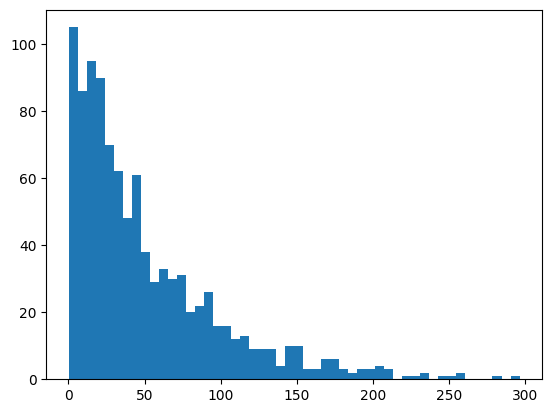

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# In NumPy, the argument you provide is the scale (β),
# The mean (average) of the values generated will be equal to the scale parameter.
data = np.random.exponential(50, 1000) 
print(f"Mean of samples: {np.mean(data)}") # Should be close to 50
plt.hist(data, bins=50)
plt.show()


In [ ]:
"""
Level-wise vs Leaf-wise Tree Growth: Practical Example
Demonstrates how tree growth strategy affects overfitting on fraud data.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

# ============================================================
# 1. CREATE SYNTHETIC FRAUD DATA
# ============================================================
np.random.seed(42)
n_samples = 5000

# Feature 1: Transaction amount (fraud tends to be extreme)
X_amount = np.random.exponential(scale=50, size=n_samples)

# Feature 2: Merchant risk score (fraud congregates in high-risk merchants)
X_risk = np.random.uniform(0, 1, n_samples)

# Feature 3: Day of week (some patterns)
X_dow = np.random.randint(0, 7, n_samples)

# Feature 4: Hour of day (fraud at odd hours)
X_hour = np.random.randint(0, 24, n_samples)

X = pd.DataFrame({
    'amount': X_amount,
    'merchant_risk': X_risk,
    'day_of_week': X_dow,
    'hour': X_hour
})

# Fraud signal: high amount + high risk merchant = fraud
y = ((X['amount'] > 80) & (X['merchant_risk'] > 0.7)).astype(int)
# Add noise: ~15% noise fraud cases that aren't captured by this rule
noise_idx = np.random.choice(len(y), size=int(0.15 * len(y)), replace=False)
y.iloc[noise_idx] = 1 - y.iloc[noise_idx]

# Split into train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)} ({y_train.mean():.1%} fraud)")
print(f"Val:   {len(X_val)} ({y_val.mean():.1%} fraud)")
print(f"Test:  {len(X_test)} ({y_test.mean():.1%} fraud)")

# ============================================================
# 2. LEVEL-WISE: XGBoost with max_depth control
# ============================================================
print("\n" + "="*60)
print("LEVEL-WISE (XGBoost): max_depth=3")
print("="*60)

xgb_model = XGBClassifier(
    max_depth=3,           # Explicit depth limit → balanced tree
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss', # objective function used to measure the error during the training process, and punish uncertainty: single observation Logloss=−(y⋅log(p)+(1−y)⋅log(1−p))
    tree_method='hist' # decides where to 'split' the data. 
)

xgb_model.fit(X_train, y_train, 
              eval_set=[(X_val, y_val)],
              verbose=False)

# Predictions
y_train_pred_xgb = xgb_model.predict_proba(X_train)[:, 1]
y_val_pred_xgb = xgb_model.predict_proba(X_val)[:, 1]
y_test_pred_xgb = xgb_model.predict_proba(X_test)[:, 1]

train_auc_xgb = roc_auc_score(y_train, y_train_pred_xgb)
val_auc_xgb = roc_auc_score(y_val, y_val_pred_xgb)
test_auc_xgb = roc_auc_score(y_test, y_test_pred_xgb)

train_ap_xgb = average_precision_score(y_train, y_train_pred_xgb)
val_ap_xgb = average_precision_score(y_val, y_val_pred_xgb)
test_ap_xgb = average_precision_score(y_test, y_test_pred_xgb)

print(f"Train AUC: {train_auc_xgb:.4f}  |  Train AP: {train_ap_xgb:.4f}")
print(f"Val AUC:   {val_auc_xgb:.4f}   |  Val AP:   {val_ap_xgb:.4f}")
print(f"Test AUC:  {test_auc_xgb:.4f}   |  Test AP:  {test_ap_xgb:.4f}")
print(f"Val-Test gap (AUC): {(val_auc_xgb - test_auc_xgb):.4f}")

# ============================================================
# 3. LEAF-WISE (AGGRESSIVE): LightGBM with num_leaves only
# ============================================================
print("\n" + "="*60)
print("LEAF-WISE (LightGBM): num_leaves=64 (NO regularization)")
print("="*60)

lgb_aggressive = LGBMClassifier(
    num_leaves=64,         # Aggressive: allow deep leaves
    n_estimators=100,
    learning_rate=0.1,
    lambda_l1=0,           # No regularization
    lambda_l2=0,
    min_data_in_leaf=1,    # Dangerous: allow 1 sample per leaf
    random_state=42,
    verbose=-1
)

lgb_aggressive.fit(X_train, y_train, eval_X=X_val, eval_y=y_val)

y_train_pred_lgb_agg = lgb_aggressive.predict_proba(X_train)[:, 1]
y_val_pred_lgb_agg = lgb_aggressive.predict_proba(X_val)[:, 1]
y_test_pred_lgb_agg = lgb_aggressive.predict_proba(X_test)[:, 1]

train_auc_lgb_agg = roc_auc_score(y_train, y_train_pred_lgb_agg)
val_auc_lgb_agg = roc_auc_score(y_val, y_val_pred_lgb_agg)
test_auc_lgb_agg = roc_auc_score(y_test, y_test_pred_lgb_agg)

train_ap_lgb_agg = average_precision_score(y_train, y_train_pred_lgb_agg)
val_ap_lgb_agg = average_precision_score(y_val, y_val_pred_lgb_agg)
test_ap_lgb_agg = average_precision_score(y_test, y_test_pred_lgb_agg)

print(f"Train AUC: {train_auc_lgb_agg:.4f}  |  Train AP: {train_ap_lgb_agg:.4f}")
print(f"Val AUC:   {val_auc_lgb_agg:.4f}   |  Val AP:   {val_ap_lgb_agg:.4f}")
print(f"Test AUC:  {test_auc_lgb_agg:.4f}   |  Test AP:  {test_ap_lgb_agg:.4f}")
print(f"Val-Test gap (AUC): {(val_auc_lgb_agg - test_auc_lgb_agg):.4f}  ⚠️ OVERFITTING")

# ============================================================
# 4. LEAF-WISE (REGULARIZED): LightGBM with strict constraints
# ============================================================
print("\n" + "="*60)
print("LEAF-WISE (LightGBM): REGULARIZED (num_leaves=16, min_data_in_leaf=50)")
print("="*60)

lgb_regular = LGBMClassifier(
    num_leaves=16,         # Conservative: fewer leaves
    n_estimators=100,
    learning_rate=0.1,
    lambda_l1=1.0,         # L1 regularization on leaf weights
    lambda_l2=1.0,         # L2 regularization
    min_data_in_leaf=50,   # Enforce min 50 samples per leaf (prevents noise fitting)
    random_state=42,
    verbose=-1
)

lgb_regular.fit(X_train, y_train, eval_X=X_val, eval_y=y_val)

y_train_pred_lgb_reg = lgb_regular.predict_proba(X_train)[:, 1]
y_val_pred_lgb_reg = lgb_regular.predict_proba(X_val)[:, 1]
y_test_pred_lgb_reg = lgb_regular.predict_proba(X_test)[:, 1]

train_auc_lgb_reg = roc_auc_score(y_train, y_train_pred_lgb_reg)
val_auc_lgb_reg = roc_auc_score(y_val, y_val_pred_lgb_reg)
test_auc_lgb_reg = roc_auc_score(y_test, y_test_pred_lgb_reg)

train_ap_lgb_reg = average_precision_score(y_train, y_train_pred_lgb_reg)
val_ap_lgb_reg = average_precision_score(y_val, y_val_pred_lgb_reg)
test_ap_lgb_reg = average_precision_score(y_test, y_test_pred_lgb_reg)

print(f"Train AUC: {train_auc_lgb_reg:.4f}  |  Train AP: {train_ap_lgb_reg:.4f}")
print(f"Val AUC:   {val_auc_lgb_reg:.4f}   |  Val AP:   {val_ap_lgb_reg:.4f}")
print(f"Test AUC:  {test_auc_lgb_reg:.4f}   |  Test AP:  {test_ap_lgb_reg:.4f}")
print(f"Val-Test gap (AUC): {(val_auc_lgb_reg - test_auc_lgb_reg):.4f}  ✓ BALANCED")

# ============================================================
# 5. SUMMARY & INSIGHTS
# ============================================================
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

summary = pd.DataFrame({
    'Model': [
        'XGBoost (level-wise, d=3)',
        'LightGBM (leaf-wise, unregularized)',
        'LightGBM (leaf-wise, regularized)'
    ],
    'Train AUC': [train_auc_xgb, train_auc_lgb_agg, train_auc_lgb_reg],
    'Val AUC': [val_auc_xgb, val_auc_lgb_agg, val_auc_lgb_reg],
    'Test AUC': [test_auc_xgb, test_auc_lgb_agg, test_auc_lgb_reg],
    'Val-Test Gap': [
        val_auc_xgb - test_auc_xgb,
        val_auc_lgb_agg - test_auc_lgb_agg,
        val_auc_lgb_reg - test_auc_lgb_reg
    ],
    'Train AP': [train_ap_xgb, train_ap_lgb_agg, train_ap_lgb_reg],
})

print(summary.to_string(index=False))

print("\n📊 KEY OBSERVATIONS:")
print(f"  1. XGBoost (level-wise): Smaller val-test gap ({(val_auc_xgb - test_auc_xgb):.4f})")
print(f"     → Safer but potentially underfitting")
print(f"\n  2. LightGBM (unregularized): LARGE val-test gap ({(val_auc_lgb_agg - test_auc_lgb_agg):.4f})")
print(f"     → High train/val accuracy masks poor generalization")
print(f"\n  3. LightGBM (regularized): Reduced gap ({(val_auc_lgb_reg - test_auc_lgb_reg):.4f})")
print(f"     → Strict min_data_in_leaf + L1/L2 prevents overfitting")
print(f"\n💡 FOR SENTINELPAY:")
print(f"  → Use LightGBM with min_data_in_leaf>=50 and lambda_l1/l2 tuning")
print(f"  → Prefer val-test correlation > absolute train accuracy")

Train: 3000 (19.1% fraud)
Val:   1000 (19.1% fraud)
Test:  1000 (19.1% fraud)

LEVEL-WISE (XGBoost): max_depth=3
Train AUC: 0.8129  |  Train AP: 0.6146
Val AUC:   0.6024   |  Val AP:   0.4291
Test AUC:  0.6273   |  Test AP:  0.4096
Val-Test gap (AUC): -0.0249

LEAF-WISE (LightGBM): num_leaves=64 (NO regularization)
Train AUC: 1.0000  |  Train AP: 0.9998
Val AUC:   0.5856   |  Val AP:   0.4067
Test AUC:  0.6245   |  Test AP:  0.3902
Val-Test gap (AUC): -0.0389  ⚠️ OVERFITTING

LEAF-WISE (LightGBM): REGULARIZED (num_leaves=16, min_data_in_leaf=50)
Train AUC: 0.8924  |  Train AP: 0.7156
Val AUC:   0.6210   |  Val AP:   0.4239
Test AUC:  0.6437   |  Test AP:  0.4188
Val-Test gap (AUC): -0.0227  ✓ BALANCED

SUMMARY
                              Model  Train AUC  Val AUC  Test AUC  Val-Test Gap  Train AP
          XGBoost (level-wise, d=3)   0.812852 0.602434  0.627292     -0.024858  0.614644
LightGBM (leaf-wise, unregularized)   0.999955 0.585598  0.624535     -0.038937  0.999810
  LightGBM